# VGG 16 with Transfer Learning

### Importing Libraries

In [1]:
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
import tensorflow as tf
from tensorflow import keras
import tf_keras
from keras.layers import Input, Lambda, Dense, Flatten, GlobalAveragePooling2D, Dropout
from keras.models import Model
from tensorflow.keras import models, layers
from keras.applications.vgg16 import VGG16
from tensorflow.keras.optimizers import Adam
from keras.applications.vgg16 import preprocess_input
import tensorflow_datasets as tfds
from tensorflow.keras.utils import to_categorical
from keras.preprocessing import image
from keras.models import Sequential

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### Data Preprocessing

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = [224,224]
SEED = 123
VALIDATION_SPLIT = 0.1
TEST_SPLIT = 0.1

In [4]:
# Load the entire dataset
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'dataset-original',
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED #Shuffle
)

Found 2527 files belonging to 6 classes.


In [5]:
dataset_name = full_ds
class_names = dataset_name.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [6]:
# Calculate splits based on NUMBER OF BATCHES (not images)
total_batches = len(full_ds)
num_test_batches = int(total_batches * TEST_SPLIT)
num_val_batches = int(total_batches * VALIDATION_SPLIT)
num_train_batches = total_batches - num_test_batches - num_val_batches

print(f'Total Batches: {total_batches}')
print(f'Batches allocated for Training: {num_train_batches}')
print(f'Batches allocated for Validation: {num_val_batches}')
print(f'Batches allocated for Testing: {num_test_batches}')

# Approximate total images (last batch might be smaller)
approx_total_images = total_batches * BATCH_SIZE
print(f'Approximate Total Images: {approx_total_images}')

# Create datasets using batch-based slicing
train_ds = full_ds.take(num_train_batches)
val_ds = full_ds.skip(num_train_batches).take(num_val_batches)
test_ds = full_ds.skip(num_train_batches + num_val_batches)

def count_images_in_dataset(dataset):
    count = 0
    for batch in dataset:
        count += batch[0].shape[0]  # batch[0] is images, shape[0] is batch size
    return count

print(f'Actual images in train_ds: {count_images_in_dataset(train_ds)}')
print(f'Actual images in val_ds: {count_images_in_dataset(val_ds)}')
print(f'Actual images in test_ds: {count_images_in_dataset(test_ds)}')

Total Batches: 79
Batches allocated for Training: 65
Batches allocated for Validation: 7
Batches allocated for Testing: 7
Approximate Total Images: 2528
Actual images in train_ds: 2080
Actual images in val_ds: 224
Actual images in test_ds: 223


In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

In [8]:
# Use preprocess_input
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Model Training

In [11]:
pretrained_model = tf_keras.applications.VGG16(
    include_top=False,
    input_shape=(224,224,3),
    pooling=None, # removed avg to be able to use GlobalAveragePooling2D
    weights='imagenet'
)

# Unfreeze the last few layers for fine-tuning
for layer in pretrained_model.layers[:-20]:  # Freeze first layers
    layer.trainable = False
for layer in pretrained_model.layers[-20:]:  # Unfreeze last 20 layers
    layer.trainable = True
      
vgg16_model = tf_keras.Sequential([
    pretrained_model,
    tf_keras.layers.GlobalAveragePooling2D(),
    tf_keras.layers.BatchNormalization(),
    tf_keras.layers.Dropout(0.5),
    tf_keras.layers.Dense(512, activation='relu'),
    tf_keras.layers.BatchNormalization(),
    tf_keras.layers.Dropout(0.3),
    tf_keras.layers.Dense(256, activation='relu'),
    tf_keras.layers.Dropout(0.2),
    tf_keras.layers.Dense(6, activation='softmax')
])

In [12]:
vgg16_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d_1  (None, 512)               0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_2 (Bat  (None, 512)               2048      
 chNormalization)                                                
                                                                 
 dropout_3 (Dropout)         (None, 512)               0         
                                                                 
 dense_3 (Dense)             (None, 512)               262656    
                                                                 
 batch_normalization_3 (Bat  (None, 512)              

In [13]:
vgg16_model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
# Callbacks for better training
callbacks = [
    tf_keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    tf_keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

In [25]:
history = vgg16_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
65/65 [==============================] - 453s 7s/step - loss: 1.1461 - accuracy: 0.5803 - val_loss: 2.1366 - val_accuracy: 0.3705 - lr: 1.0000e-04
Epoch 2/10
65/65 [==============================] - 457s 7s/step - loss: 0.9769 - accuracy: 0.6313 - val_loss: 1.7780 - val_accuracy: 0.3304 - lr: 1.0000e-04
Epoch 3/10
65/65 [==============================] - 456s 7s/step - loss: 0.8793 - accuracy: 0.6788 - val_loss: 3.2760 - val_accuracy: 0.3750 - lr: 1.0000e-04
Epoch 4/10
65/65 [==============================] - 455s 7s/step - loss: 0.8462 - accuracy: 0.6769 - val_loss: 1.6203 - val_accuracy: 0.3929 - lr: 1.0000e-04
Epoch 5/10
65/65 [==============================] - 455s 7s/step - loss: 0.7661 - accuracy: 0.7173 - val_loss: 0.8702 - val_accuracy: 0.6607 - lr: 1.0000e-04
Epoch 6/10
65/65 [==============================] - 455s 7s/step - loss: 0.5619 - accuracy: 0.8000 - val_loss: 0.6549 - val_accuracy: 0.7500 - lr: 1.0000e-04
Epoch 7/10
65/65 [==============================] - 

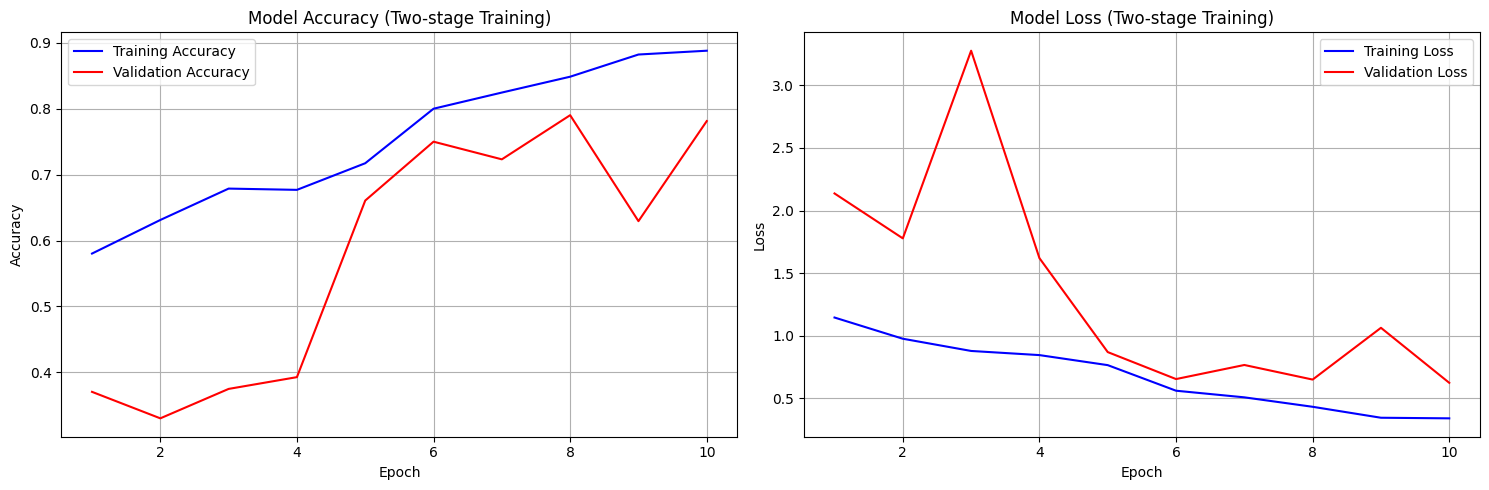

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
total_epochs = 10

ax1.plot(range(1, total_epochs + 1), history.history['accuracy'], 'b-', label='Training Accuracy')
ax1.plot(range(1, total_epochs + 1), history.history['val_accuracy'], 'r-', label='Validation Accuracy')
ax1.set_title('Model Accuracy (Two-stage Training)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(range(1, total_epochs + 1), history.history['loss'], 'b-', label='Training Loss')
ax2.plot(range(1, total_epochs + 1), history.history['val_loss'], 'r-', label='Validation Loss')
ax2.set_title('Model Loss (Two-stage Training)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [27]:
# Final evaluation
print("\n" + "="*50)
print("FINAL MODEL EVALUATION")
print("="*50)

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
best_val_acc = max(history.history['val_accuracy'])

print(f"Final Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"Final Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


FINAL MODEL EVALUATION
Final Training Accuracy: 0.8880 (88.80%)
Final Validation Accuracy: 0.7812 (78.12%)
Best Validation Accuracy: 0.7902 (79.02%)


### Evaluation

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [29]:
# Get predictions from the test dataset
y_true = []  # True labels
y_pred = []  # Predicted labels

# Iterate through the test dataset to collect true labels and predictions
for images, labels in test_ds:
    predictions = vgg16_model.predict(images)
    y_true.extend(labels.numpy())  # Append true labels
    y_pred.extend(np.argmax(predictions, axis=1))  # Append predicted labels

# Convert lists to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 [==============================] - 3s 3s/step


In [30]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
error_rate = 1 - accuracy

print("\n" + "="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")


MODEL EVALUATION METRICS
Accuracy: 0.7623 (76.23%)
Precision (weighted): 0.8240
Recall (weighted): 0.7623
F1-Score (weighted): 0.7698
Error Rate: 0.2377 (23.77%)


In [31]:
# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

              precision    recall  f1-score   support

   cardboard       0.83      0.81      0.82        42
       glass       0.86      0.67      0.76        46
       metal       0.94      0.48      0.64        33
       paper       0.96      0.85      0.90        55
     plastic       0.60      0.95      0.73        38
       trash       0.30      0.67      0.41         9

    accuracy                           0.76       223
   macro avg       0.75      0.74      0.71       223
weighted avg       0.82      0.76      0.77       223




CONFUSION MATRIX
Raw confusion matrix:
[[34  0  0  1  1  6]
 [ 1 31  1  0 11  2]
 [ 3  4 16  0  9  1]
 [ 3  0  0 47  1  4]
 [ 0  1  0  0 36  1]
 [ 0  0  0  1  2  6]]


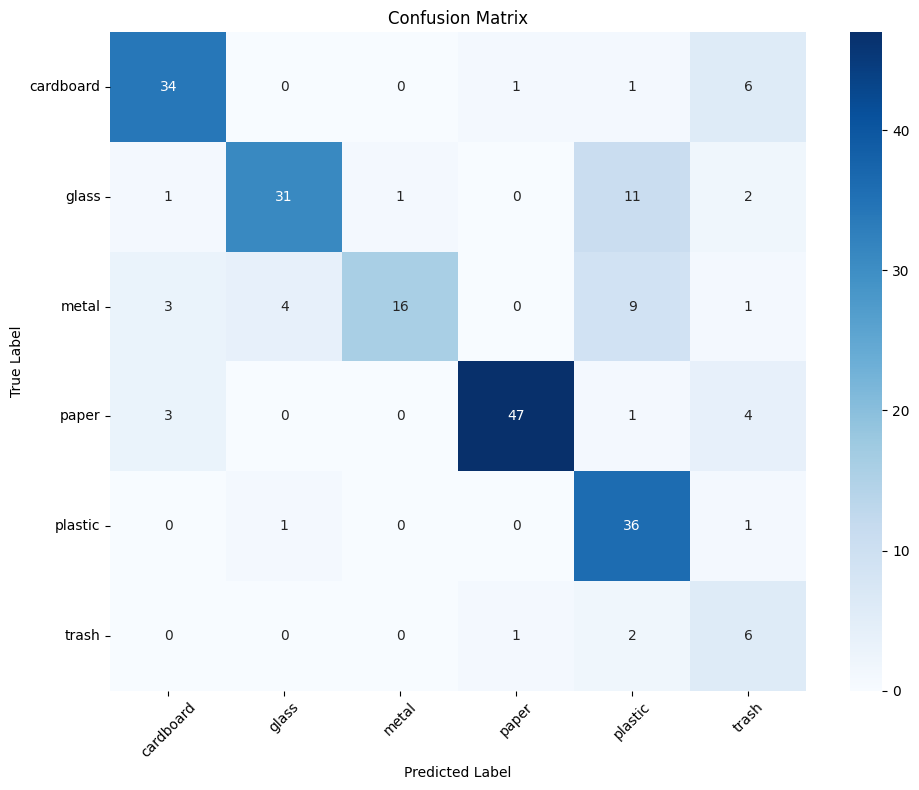

In [32]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
print("Raw confusion matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Save model

In [33]:
# Save model
vgg16_model.save('vgg16_model.h5')
print(f"\n Model saved as 'vgg16_model.h5'")

C:\Users\Hasya Hazizi\anaconda3\envs\FYP\Lib\site-packages\tf_keras\src\engine\training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



 Model saved as 'vgg16_model.h5'
